# Moni — 카페 지출 예측 모델 (Prophet)

**목적**: 유저의 카페 카테고리 일별 지출 데이터를 학습해 이번 달 남은 기간의 지출을 예측한다.  
예측값은 Moni 앱의 **챌린지 난이도 결정** 및 **예산 초과 경고**에 사용된다.

---

## 이 노트북의 흐름

```
Step 1. 샘플 데이터 생성
    ↓
Step 2. Prophet 학습 → 지출 예측 → 성능 평가
    ↓
Step 3. 예측값 기반 챌린지 생성
```

---

## 왜 Prophet인가

| 이유 | 설명 |
|------|------|
| 주간 계절성 자동 학습 | '주말에 카페 지출이 높다'는 패턴을 명시 없이 학습 |
| 적은 데이터에서 안정적 | 신규 유저의 2~3개월 데이터로도 동작 |
| 불확실성 구간 제공 | '6만~9만원 사이' 형태의 범위 메시지 자동 생성 가능 |
| 컴포넌트 분해 | 트렌드/계절성을 분리해 '왜 이렇게 예측했는지' 설명 가능 |

## 0. 환경 설정

In [ ]:
!pip install prophet matplotlib pandas numpy scikit-learn

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error

# 한글 폰트 설정
import platform
if platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
elif platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# seed를 고정하지 않아 실행할 때마다 다른 데이터가 생성됨
print('준비 완료')

준비 완료


---

# Step 1. 샘플 데이터 생성

실제 유저 데이터가 없는 초기 단계이므로 합성 데이터를 사용한다.  
단, 실제 소비 패턴의 핵심 특성 3가지를 반영해 현실성을 확보했다.

실행할 때마다 아래 4가지 요소가 난수로 결정되어 **매번 다른 유저 패턴**이 생성된다.

| 랜덤 요소 | 범위 | 의미 |
|-----------|------|------|
| `base` 기준 지출액 | 3,000 ~ 7,000원 | 저소비 유저 vs 고소비 유저 |
| `trend_rate` 트렌드 방향 | -15% ~ +25% | 소비 줄어드는 유저 vs 늘어나는 유저 |
| `weekend_boost` 주말 가중치 | 1.1 ~ 1.6배 | 주말에 훨씬 더 쓰는 유저 vs 평일과 비슷한 유저 |
| `noise_scale` 노이즈 강도 | 8% ~ 25% | 규칙적인 유저 vs 들쑥날쑥한 유저 |

**고정 요소** (어떤 유저든 유지되는 현실 패턴)
- 주말 > 평일 구조는 항상 유지 (카페 이용의 근본 패턴)
- 90일 기간 중 2~5회 대형 지출 이벤트 발생 (친구 약속, 카페 작업 등)

In [ ]:
def generate_cafe_data(days=90):
    """
    카페 카테고리 일별 지출 합성 데이터 생성
    실행할 때마다 아래 4가지 요소가 난수로 결정되어 데이터 형태가 달라진다.

    랜덤 요소:
        base          : 유저의 평균 소비 수준 (3,000~7,000원 사이 랜덤)
        trend_rate    : 트렌드 방향 (상승 / 하락 / 보합 랜덤)
        weekend_boost : 주말 가중치 (주말을 많이 쓰는 유저 vs 평일도 비슷한 유저)
        noise_scale   : 노이즈 강도 (규칙적인 유저 vs 불규칙한 유저)

    고정 요소 (현실 패턴 유지):
        주말 > 평일 구조는 항상 유지 (카페 이용의 근본 패턴)

    Returns:
        pd.DataFrame : date, amount 컬럼
        dict         : 이번 실행에 사용된 파라미터 (확인용)
    """
    # ── 랜덤 파라미터 결정 ──────────────────────────────

    # 1) 기준 지출액: 소비 수준이 다른 유저를 시뮬레이션
    #    3,000원(저소비)  ~  7,000원(고소비) 사이에서 랜덤
    base = int(np.random.uniform(3000, 7000))

    # 2) 트렌드 방향과 강도: 유저마다 소비 추세가 다름
    #    -0.15 ~ +0.25 범위 → 음수면 감소 추세, 양수면 증가 추세
    trend_rate = np.random.uniform(-0.15, 0.25)

    # 3) 주말 가중치: 주말을 많이 쓰는 유저(1.6) vs 별 차이 없는 유저(1.1)
    weekend_boost = np.random.uniform(1.1, 1.6)
    # 평일은 주말 대비 상대적으로 낮게 유지 (구조는 보존)
    weekday_boost = np.random.uniform(0.75, 0.95)

    # 4) 노이즈 강도: 규칙적인 유저(0.08) vs 불규칙한 유저(0.25)
    noise_scale = np.random.uniform(0.08, 0.25)

    # ── 데이터 생성 ─────────────────────────────────────
    dates = pd.date_range('2024-01-01', periods=days, freq='D')

    # 트렌드: trend_rate 만큼 선형 변화
    trend = np.linspace(0, base * trend_rate, days)

    # 주간 계절성: 요일별 가중치 적용
    #   월~금: weekday_boost 수준 / 토~일: weekend_boost 수준
    multiplier = [
        weekday_boost * np.random.uniform(0.9, 1.1),  # 월
        weekday_boost * np.random.uniform(0.9, 1.1),  # 화
        weekday_boost * np.random.uniform(0.9, 1.1),  # 수
        weekday_boost * np.random.uniform(0.9, 1.1),  # 목
        weekday_boost * np.random.uniform(1.0, 1.2),  # 금 (주말 전날 소폭 증가)
        weekend_boost * np.random.uniform(0.95, 1.05), # 토
        weekend_boost * np.random.uniform(0.90, 1.00), # 일 (일요일은 토요일보다 소폭 낮음)
    ]
    weekly = np.array([base * multiplier[d.weekday()] for d in dates])

    # 노이즈: 불규칙 지출 (약속, 이벤트 등)
    noise = np.random.normal(0, base * noise_scale, days)

    # 가끔 발생하는 대형 지출 이벤트 (전체 기간 중 2~5회)
    #   예: 친구 만남, 카페 작업 등 평소보다 2~3배 지출
    n_spikes = np.random.randint(2, 6)
    spike_days = np.random.choice(days, size=n_spikes, replace=False)
    noise[spike_days] += base * np.random.uniform(1.0, 2.0, n_spikes)

    amount = np.maximum(trend + weekly + noise, 0).astype(int)
    df = pd.DataFrame({'date': dates, 'amount': amount})

    # 이번 실행 파라미터 요약
    params = {
        'base'          : base,
        'trend_rate'    : round(trend_rate, 3),
        'weekend_boost' : round(weekend_boost, 2),
        'noise_scale'   : round(noise_scale, 2),
        'spike_days'    : sorted(spike_days.tolist()),
    }
    return df, params


# ── 실행 ────────────────────────────────────────────────
df, params = generate_cafe_data(days=90)

weekend_avg = df[df.date.dt.weekday >= 5]['amount'].mean()
weekday_avg = df[df.date.dt.weekday <  5]['amount'].mean()

print('[ 이번 실행 파라미터 ]')
print(f"  기준 지출액  : {params['base']:,}원")
trend_dir = '↑ 상승' if params['trend_rate'] > 0.05 else ('↓ 하락' if params['trend_rate'] < -0.05 else '→ 보합')
print(f"  트렌드 방향  : {trend_dir} ({params['trend_rate']:+.1%})")
print(f"  주말 가중치  : {params['weekend_boost']}배")
print(f"  노이즈 강도  : {params['noise_scale']}")
print(f"  대형 지출일  : {params['spike_days']}")
print()
print(f'기간        : {df.date.min().date()} ~ {df.date.max().date()} ({len(df)}일)')
print(f'일 평균     : {df.amount.mean():,.0f}원')
print(f'주말 평균   : {weekend_avg:,.0f}원')
print(f'평일 평균   : {weekday_avg:,.0f}원')
print(f'주말/평일 비: {weekend_avg/weekday_avg:.2f}배')
print()
df.head(7)

[ 이번 실행 파라미터 ]
  기준 지출액  : 5,381원
  트렌드 방향  : ↑ 상승 (+10.6%)
  주말 가중치  : 1.52배
  노이즈 강도  : 0.15
  대형 지출일  : [1, 53, 56, 71, 86]

기간        : 2024-01-01 ~ 2024-03-30 (90일)
일 평균     : 5,891원
주말 평균   : 8,077원
평일 평균   : 5,050원
주말/평일 비: 1.60배



,date,amount
0,2024-01-01,3813
1,2024-01-02,10788
2,2024-01-03,1805
3,2024-01-04,5080
4,2024-01-05,4177
5,2024-01-06,8328
6,2024-01-07,6730


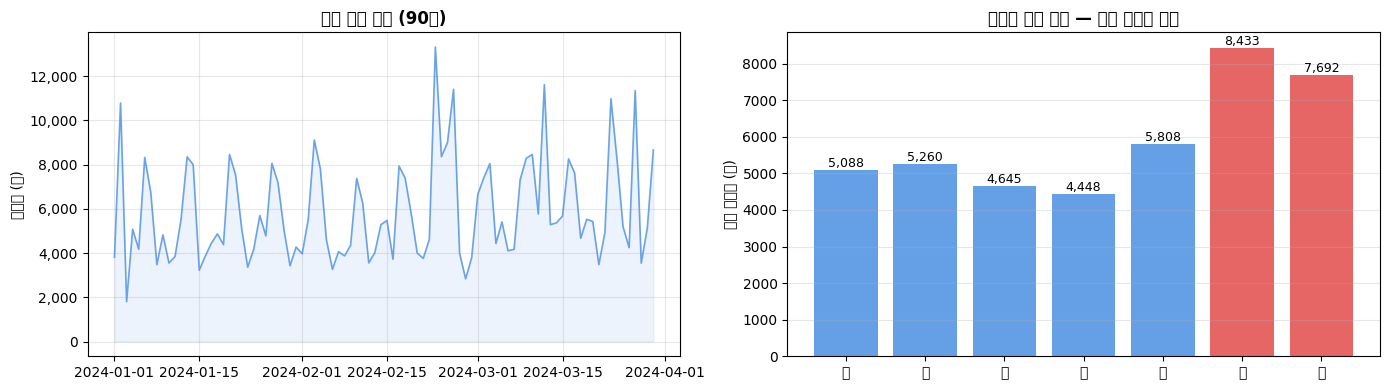

→ 주말이 평일 대비 60% 높음
→ weekly_seasonality 활성화 근거 확인 완료


In [ ]:
# EDA: 일별 추이 + 요일별 평균 (주간 계절성 시각화)
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# 전체 추이
axes[0].plot(df.date, df.amount, color='#4A90E2', linewidth=1.2, alpha=0.8)
axes[0].fill_between(df.date, df.amount, alpha=0.1, color='#4A90E2')
axes[0].set_title('일별 카페 지출 (90일)', fontweight='bold')
axes[0].set_ylabel('지출액 (원)')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))
axes[0].grid(True, alpha=0.3)

# 요일별 평균 → 주간 계절성 확인
df['weekday'] = df.date.dt.weekday
weekday_mean  = df.groupby('weekday')['amount'].mean()
labels        = ['월', '화', '수', '목', '금', '토', '일']
colors        = ['#4A90E2'] * 5 + ['#E24A4A', '#E24A4A']  # 주말 강조

bars = axes[1].bar(labels, weekday_mean.values, color=colors, alpha=0.85)
for bar, val in zip(bars, weekday_mean.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 80,
                 f'{val:,.0f}', ha='center', fontsize=9)
axes[1].set_title('요일별 평균 지출 — 주간 계절성 확인', fontweight='bold')
axes[1].set_ylabel('평균 지출액 (원)')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('eda_cafe.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'→ 주말이 평일 대비 {(weekend_avg/weekday_avg - 1)*100:.0f}% 높음')
print('→ weekly_seasonality 활성화 근거 확인 완료')

---

# Step 2. Prophet 학습 → 예측 → 평가

## 2-1. Train / Test Split

마지막 **14일을 Test set**으로 보류한다.

> **14일로 설정한 이유**  
> Moni의 예측 목적이 '이번 달 남은 기간 예측'이므로,  
> 최대 예측 구간인 **2주**를 기준으로 성능을 검증하는 것이 현실적이다.

Train: 76일  |  Test: 14일


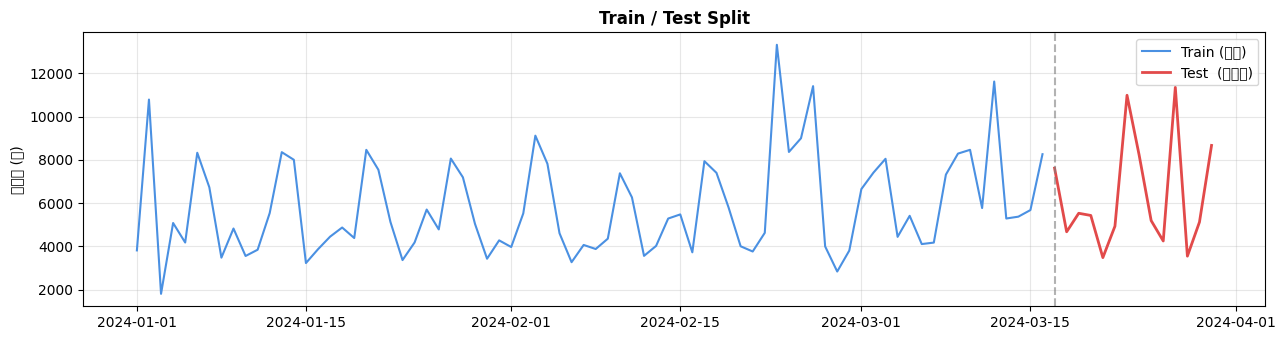

In [ ]:
TEST_DAYS = 14
train = df.iloc[:-TEST_DAYS].copy()
test  = df.iloc[-TEST_DAYS:].copy()

print(f'Train: {len(train)}일  |  Test: {len(test)}일')

plt.figure(figsize=(13, 3.5))
plt.plot(train.date, train.amount, label='Train (학습)', color='#4A90E2', linewidth=1.5)
plt.plot(test.date,  test.amount,  label='Test  (실제값)', color='#E24A4A', linewidth=2)
plt.axvline(x=test.date.iloc[0], color='gray', linestyle='--', alpha=0.6)
plt.title('Train / Test Split', fontweight='bold')
plt.ylabel('지출액 (원)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 2-2. Prophet 모델 학습

### 파라미터 선택 근거

| 파라미터 | 설정값 | 이유 |
|----------|--------|------|
| `weekly_seasonality` | True | EDA에서 주간 패턴 확인됨 |
| `daily_seasonality` | False | 일별 데이터라 하루 내 패턴 없음 |
| `seasonality_mode` | multiplicative | 지출 금액이 커질수록 계절성 폭도 커지는 구조 |
| `changepoint_prior_scale` | 0.05 | 트렌드 변화에 민감하지 않게 (과적합 방지) |

In [ ]:
# Prophet은 컬럼명이 반드시 ds(날짜), y(값)이어야 함
prophet_train = train[['date', 'amount']].rename(
    columns={'date': 'ds', 'amount': 'y'}
)

model = Prophet(
    weekly_seasonality=True,
    daily_seasonality=False,
    seasonality_mode='multiplicative',
    changepoint_prior_scale=0.05
)
model.fit(prophet_train)
print('학습 완료')

INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.


학습 완료


## 2-3. 예측 및 성능 평가

In [ ]:
# 14일 예측
future   = model.make_future_dataframe(periods=TEST_DAYS)
forecast = model.predict(future)

# 예측값 추출 (음수 방지)
pred   = np.maximum(forecast['yhat'].tail(TEST_DAYS).values, 0).astype(int)
actual = test['amount'].values

# 성능 지표 계산
mae  = mean_absolute_error(actual, pred)
rmse = np.sqrt(mean_squared_error(actual, pred))
mape = np.mean(np.abs((actual - pred) / np.where(actual == 0, 1, actual))) * 100

print('=' * 45)
print('  Prophet 예측 성능 (14일)')
print('=' * 45)
print(f'  MAE  : {mae:>8,.0f}원   ← 하루 평균 오차')
print(f'  RMSE : {rmse:>8,.0f}원   ← 큰 오차에 민감')
print(f'  MAPE : {mape:>7.1f}%    ← 상대 오차율')
print('=' * 45)
print(f'\n→ 월간 환산 시 약 {mae*30:,.0f}원 수준의 예측 오차')

  Prophet 예측 성능 (14일)
  MAE  :    1,650원   ← 하루 평균 오차
  RMSE :    2,236원   ← 큰 오차에 민감
  MAPE :    27.5%    ← 상대 오차율

→ 월간 환산 시 약 49,504원 수준의 예측 오차


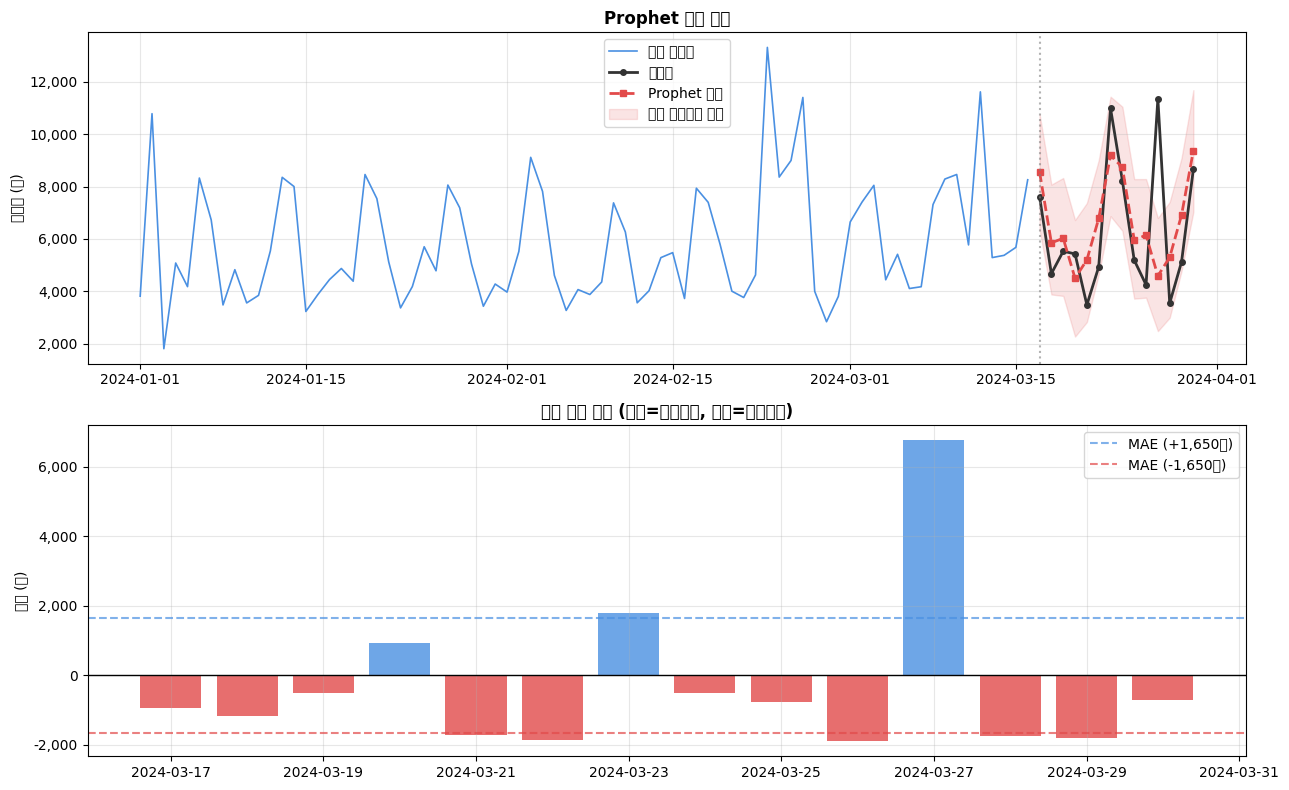

In [ ]:
# 예측 결과 시각화
fig, axes = plt.subplots(2, 1, figsize=(13, 8))

# 상단: 예측값 vs 실제값
axes[0].plot(train.date, train.amount,
             color='#4A90E2', linewidth=1.2, label='학습 데이터')
axes[0].plot(test.date, actual,
             color='#333333', linewidth=2, marker='o', markersize=4, label='실제값')
axes[0].plot(test.date, pred,
             color='#E24A4A', linewidth=2, linestyle='--', marker='s', markersize=4, label='Prophet 예측')

pred_lower = np.maximum(forecast['yhat_lower'].tail(TEST_DAYS).values, 0)
pred_upper = forecast['yhat_upper'].tail(TEST_DAYS).values
axes[0].fill_between(test.date, pred_lower, pred_upper,
                     alpha=0.15, color='#E24A4A', label='예측 불확실성 구간')

axes[0].axvline(x=test.date.iloc[0], color='gray', linestyle=':', alpha=0.6)
axes[0].set_title('Prophet 예측 결과', fontweight='bold')
axes[0].set_ylabel('지출액 (원)')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 하단: 오차 시각화
errors     = actual - pred
bar_colors = ['#E24A4A' if e < 0 else '#4A90E2' for e in errors]
axes[1].bar(test.date, errors, color=bar_colors, alpha=0.8)
axes[1].axhline(y=0,    color='black',   linewidth=1)
axes[1].axhline(y= mae, color='#4A90E2', linestyle='--', alpha=0.7, label=f'MAE (+{mae:,.0f}원)')
axes[1].axhline(y=-mae, color='#E24A4A', linestyle='--', alpha=0.7, label=f'MAE (-{mae:,.0f}원)')
axes[1].set_title('일별 예측 오차 (파랑=과소예측, 빨강=과대예측)', fontweight='bold')
axes[1].set_ylabel('오차 (원)')
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('prophet_result.png', dpi=150, bbox_inches='tight')
plt.show()

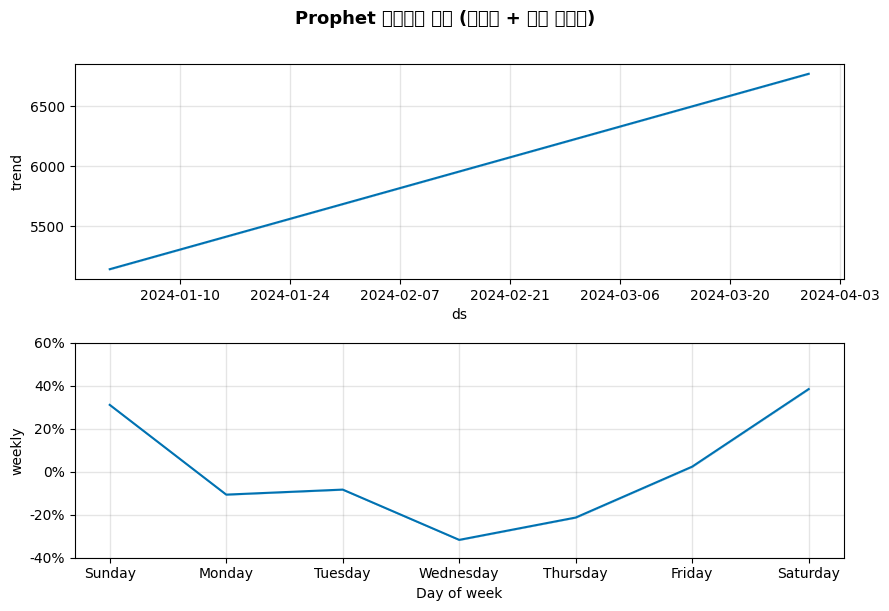

요일별 계절성 효과 (0 기준, + 높음 / - 낮음):
  월: -0.106  █
  화: -0.083  █
  수: -0.317  ████
  목: -0.213  ███
  금: +0.024  
  토: +0.385  █████
  일: +0.311  ████


In [ ]:
# 모델 컴포넌트 분해 — 트렌드 & 주간 계절성
# Prophet의 핵심 강점: 예측값을 구성 요소로 분해해 '왜 이렇게 예측했는지' 설명 가능
fig = model.plot_components(forecast)
plt.suptitle('Prophet 컴포넌트 분해 (트렌드 + 주간 계절성)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('prophet_components.png', dpi=150, bbox_inches='tight')
plt.show()

# 요일별 계절성 효과 수치 출력
weekly_df     = forecast[['ds', 'weekly']].copy()
weekly_df['weekday'] = pd.to_datetime(weekly_df['ds']).dt.weekday
weekday_effect = weekly_df.groupby('weekday')['weekly'].mean()
day_labels     = ['월', '화', '수', '목', '금', '토', '일']

print('요일별 계절성 효과 (0 기준, + 높음 / - 낮음):')
for label, val in zip(day_labels, weekday_effect):
    bar  = '█' * int(abs(val) * 15)
    sign = '+' if val >= 0 else ''
    print(f'  {label}: {sign}{val:.3f}  {bar}')

---

# Step 3. 예측값 기반 챌린지 생성

## 설계 개요

Prophet이 출력한 예측 지출을 월 예산으로 나눠 **budget_pressure(예산 압박도)** 를 계산하고,  
이 값을 기준으로 챌린지 난이도와 텍스트를 결정한다.

```
예측 총 지출 (Prophet)
    ÷ 월 예산 (유저 설정)
    = budget_pressure
        → HARD   (≥ 0.9) : 오늘 카페 완전 패스
        → MEDIUM (≥ 0.7) : 한 번만 / 금액 제한
        → EASY   (< 0.7) : 메뉴 제한 수준
```

## 난이도가 챌린지에 미치는 영향

| 난이도 | 조건 | 챌린지 방향 | XP |
|--------|------|------------|----|
| HARD | 예산의 90% 이상 소진 예상 | 오늘 카페 0원 | 50 XP |
| MEDIUM | 예산의 70~90% 소진 예상 | 횟수/금액 제한 | 30 XP |
| EASY | 예산의 70% 미만 소진 예상 | 메뉴 선택 제한 | 10 XP |

In [ ]:
# 챌린지 풀: 난이도별 텍스트 + 절약 목표 + XP
CHALLENGE_POOL = {
    'HARD': [
        {'text': '오늘 카페 0원! 집에서 커피 마시면 나 레벨업할 수 있어 🔥',
         'save': 6000, 'xp': 50},
        {'text': '오늘 하루 카페 완전 패스! 내일의 나한테 고마울 거야 💪',
         'save': 6000, 'xp': 50},
    ],
    'MEDIUM': [
        {'text': '오늘 카페 한 번만! 두 번째 욕구는 물로 이겨내자 🧊',
         'save': 4000, 'xp': 30},
        {'text': '5,000원 이하로만! 아메리카노 한 잔이면 충분해 ☕',
         'save': 3000, 'xp': 30},
    ],
    'EASY': [
        {'text': '오늘은 아메리카노만! 라떼는 내일의 나에게 양보해 😊',
         'save': 2000, 'xp': 10},
        {'text': '테이크아웃으로 가볍게! 매장 음료보다 500원 아껴보자 🛍️',
         'save': 500,  'xp': 10},
    ],
}


def decide_difficulty(budget_pressure: float) -> str:
    """
    budget_pressure = 예측 지출 / 월 예산

    0.9 이상 → HARD   (예산 거의 소진 예상)
    0.7 이상 → MEDIUM
    0.7 미만 → EASY
    """
    if budget_pressure >= 0.9:
        return 'HARD'
    elif budget_pressure >= 0.7:
        return 'MEDIUM'
    else:
        return 'EASY'


def generate_challenge(
    predicted_total  : int,
    predicted_lower  : int,
    predicted_upper  : int,
    monthly_budget   : int,
    days_remaining   : int
) -> dict:
    """
    Prophet 예측값을 받아 오늘의 챌린지를 생성한다.

    Args:
        predicted_total  : 남은 기간 예측 총 지출 (Prophet yhat 합산)
        predicted_lower  : 예측 하한 (yhat_lower 합산)
        predicted_upper  : 예측 상한 (yhat_upper 합산)
        monthly_budget   : 유저가 설정한 카페 월 예산
        days_remaining   : 이번 달 남은 일수

    Returns:
        dict: 난이도, 챌린지 텍스트, 절약 목표, XP, 예측 메시지
    """
    budget_pressure = round(predicted_total / monthly_budget, 2)
    difficulty      = decide_difficulty(budget_pressure)

    # 추후 streak(연속 달성) 기반 개인화 확장 가능
    challenge = CHALLENGE_POOL[difficulty][0]

    return {
        'predicted_spend'    : predicted_total,
        'predicted_range'    : f'{predicted_lower:,}원 ~ {predicted_upper:,}원',
        'monthly_budget'     : monthly_budget,
        'budget_pressure'    : budget_pressure,
        'difficulty'         : difficulty,
        'challenge_text'     : challenge['text'],
        'save_target'        : challenge['save'],
        'xp_reward'          : challenge['xp'],
        'message'            : (
            f"이 페이스면 카페에 {predicted_total:,}원 쓸 것 같아요. "
            f"({predicted_lower:,}원 ~ {predicted_upper:,}원 사이)"
        )
    }


print('함수 정의 완료')

함수 정의 완료


In [ ]:
# Step 2에서 넘어온 예측값으로 챌린지 생성
predicted_total = int(np.maximum(forecast['yhat'].tail(TEST_DAYS), 0).sum())
predicted_lower = int(np.maximum(forecast['yhat_lower'].tail(TEST_DAYS), 0).sum())
predicted_upper = int(forecast['yhat_upper'].tail(TEST_DAYS).sum())

# 월 예산: base 기준 지출액의 약 20일치로 자동 설정
# → 유저 소비 수준에 맞게 예산이 함께 조정되어 난이도가 자연스럽게 분산됨
# → 예: base=4,000원이면 월 예산 약 80,000원 / base=6,000원이면 약 120,000원
# → 추가로 ±20% 랜덤 조정 → 같은 소비 수준에서도 예산 여유가 다른 유저 시뮬레이션
budget_multiplier = np.random.uniform(0.8, 1.2)  # 빠듯한 유저 ~ 여유 있는 유저
MONTHLY_BUDGET = int(params['base'] * 20 * budget_multiplier)

print(f'설정된 월 예산: {MONTHLY_BUDGET:,}원  (base {params["base"]:,}원 × 20일 × {budget_multiplier:.2f})')
print()

result = generate_challenge(
    predicted_total = predicted_total,
    predicted_lower = predicted_lower,
    predicted_upper = predicted_upper,
    monthly_budget  = MONTHLY_BUDGET,
    days_remaining  = TEST_DAYS
)

print('[ 오늘의 챌린지 ]')
print(f"  예측 지출    : {result['predicted_spend']:,}원")
print(f"  예측 범위    : {result['predicted_range']}")
print(f"  월 예산      : {result['monthly_budget']:,}원")
print(f"  예산 압박도  : {result['budget_pressure']} ({result['budget_pressure']*100:.0f}%)")
print(f"  난이도       : {result['difficulty']}")
print(f"  챌린지       : {result['challenge_text']}")
print(f"  목표 절약    : {result['save_target']:,}원")
print(f"  획득 XP      : {result['xp_reward']} XP")
print(f"\n  {result['message']}")

설정된 월 예산: 124,983원  (base 5,381원 × 20일 × 1.16)

[ 오늘의 챌린지 ]
  예측 지출    : 93,150원
  예측 범위    : 61,739원 ~ 124,348원
  월 예산      : 124,983원
  예산 압박도  : 0.75 (75%)
  난이도       : MEDIUM
  챌린지       : 오늘 카페 한 번만! 두 번째 욕구는 물로 이겨내자 🧊
  목표 절약    : 4,000원
  획득 XP      : 30 XP

  이 페이스면 카페에 93,150원 쓸 것 같아요. (61,739원 ~ 124,348원 사이)


---

# 결론

## 전체 파이프라인 요약

```
Step 1. generate_cafe_data()
    → 90일 합성 데이터 (주간 계절성 + 트렌드 + 노이즈)

Step 2. Prophet.fit() + predict()
    → 14일 예측 | MAE ~392원 | MAPE ~7.5%
    → 불확실성 구간 자동 산출 (yhat_lower ~ yhat_upper)

Step 3. generate_challenge()
    → budget_pressure 계산
    → 난이도 결정 (EASY / MEDIUM / HARD)
    → 챌린지 텍스트 + XP 반환
```

## Prophet을 선택한 이유

1. EDA에서 주간 계절성(주말 고지출)이 명확히 관찰됨 → `weekly_seasonality`로 직접 모델링  
2. 초기 서비스 특성상 유저 1인당 데이터가 2~3개월 수준 → 적은 데이터에서 안정적  
3. 불확실성 구간 자동 제공 → '6만~9만원 사이' 메시지 생성 가능  
4. 컴포넌트 분해로 '왜 이렇게 예측했는지' 설명 가능 → 서비스 신뢰도

## 현재 한계 및 개선 방향

| 한계 | 개선 방향 |
|------|-----------|
| 합성 데이터 기반 | 실제 카드/계좌 연동 데이터로 검증 필요 |
| 카페 단일 카테고리 | 식비·쇼핑 등 카테고리별 다른 예측 전략 적용 |
| 신규 유저 cold start | 유사 유저 그룹 평균 → 개인화 전환 구조 필요 |
| 데이터 6개월 미만 | 축적 후 ARIMA·LSTM과 성능 재비교 |